# Processing data from the C++ program

In [ ]:
using Plots
using JuliVirBootstrap
import Polynomials: fit
using Symbolics
using JLD2
import DataFrames: DataFrame
import GLM: lm, @formula, coef

res_dir = "/home/roux/transfermatrices/On_loops/results";
cd(res_dir)

## Checking the central charge

We start by checking the central charge, which we get as

$$ -\frac1L\log \Lambda_0(L) = f_0^\infty - \frac{\pi c}{6L^2} $$

In [ ]:
# load the data, below is for λ = 0.5, n = -2cos(4λ)
Λs = load("ev_wo_defects.jld2", "Λs")
Λ0(L) = Λs[L][1];
println(Λ0(11))

-0.2444306896451367


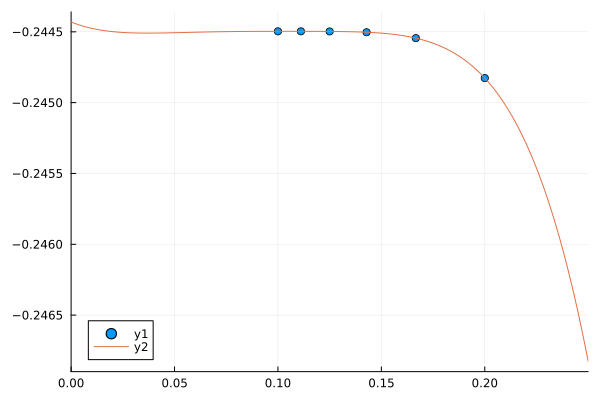

In [8]:
@variables c1, c2, c3

f0(L) = -log(real(Λ0(L)))/L

# get and effective central charge from sizes L, L+1 and L+2
eq(L) = c1 - π*c2/6/L^2 + c3/L^4 - f0(L)
c_eff(L) = Symbolics.symbolic_linear_solve([eq(L), eq(L+1), eq(L+2)], [c1, c2, c3])[2]

Lrange = 5:10
c_effs = [c_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p0 = fit(Ls, c_effs)
println(p0(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, c_effs)
plot!(xfine, p0.(xfine), xlims=(0, 0.25))

The expected central charge is 

$$
c = 13 - 6(\beta^2 + \beta^{-2})
$$

where $n = -2\cos(\pi \beta^2)$ so $\beta^2 = \frac{4\lambda}\pi$

In [49]:
λ = 0.5
β = sqrt(4λ/π)
c_exp = 13 - 6*(β^2 + 1/β^2)

-0.2444965949748692

The central charge extracted from the transfer matrix matches the expected value to a good accuracy.

### From the partition function

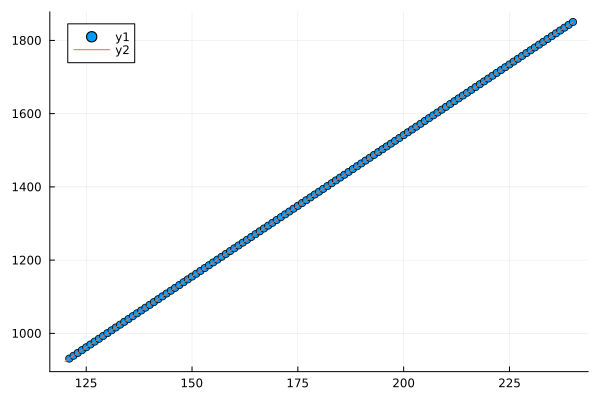

In [6]:
C10s = load("partition_function_no_defects.jld2", "data")
Ms(L) = sort([k for k in keys(C10s[L])])
C10Ls(L) = [C10s[L][M] for M in Ms(L)];

# linear fit
data(L) = DataFrame(M = Ms(L), logC10 = Float64.(log.(C10Ls(L))))
model(L) = lm(@formula(logC10 ~ M), data(L))

L=6
mesh = 120:0.1:240
plt = scatter(Ms(L), log.(C10Ls(L)))
fit(L) = coef(model(L))
plot!(plt, mesh, fit(L)[1] .+ fit(L)[2].*mesh)
display(plt)

logΛ0(L) = fit(L)[2];

-0.2444306896451367


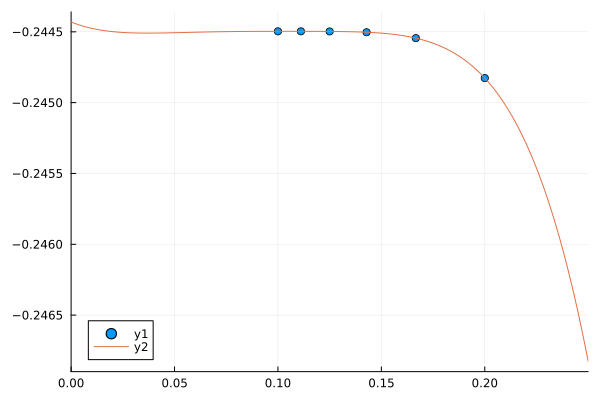

In [7]:
@variables c1, c2, c3

f02p(L) = -logΛ0(L)/L

# get and effective central charge from sizes L, L+1 and L+2
eq(L) = c1 - π*c2/6/L^2 + c3/L^4 - f0(L)
c_eff(L) = Symbolics.solve_for([eq(L), eq(L+1), eq(L+2)], [c1, c2, c3])[2]

Lrange = 5:10
c_effs = [c_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p0 = fit(Ls, c_effs)
println(p0(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, c_effs)
plot!(xfine, p0.(xfine), xlims=(0, 0.25))

## Two-point function of the two-leg operator
### From the spectrum

We extract the dimension of the two-leg operator thanks to

$$
-\frac{1}{L} \log(\frac{\Lambda(L)}{\Lambda_0(L)}) = \frac{2\pi\Delta}{L^2} + o(L^{-2}).
$$

where $\Lambda$ is the highest eigenvalue in the sector with two defects.

In [8]:
# load the data, below is for λ = 0.5, n = -2cos(4λ)
Λ1s = load("ev_2_defects.jld2", "Λs")
Λ1(L) = Λ1s[L][1];
println(log(real(Λ1(6))))

7.497229800126788


0.21463890276744862


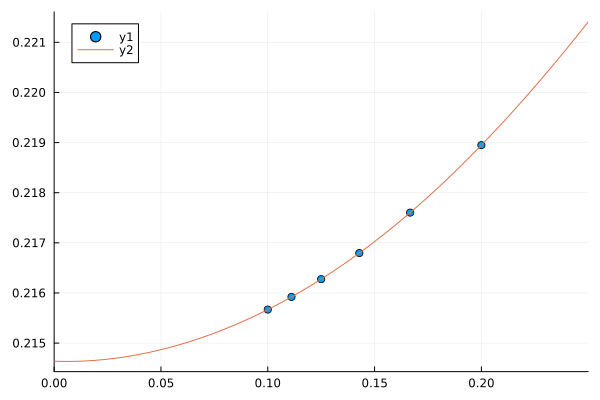

In [9]:
@variables Δ

f1(L) = -log(real(Λ1(L)))/L

# get an effective scaling dimension at size L
eq(L) = f1(L)-f0(L) - π*Δ*2/L^2
Δ_eff(L) = Symbolics.value(Symbolics.solve_for(eq(L), Δ))

Lrange = 5:10
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
plot!(xfine, p1.(xfine), xlims=(0, 0.25))

The expected result is $2\Delta_{(1, 0)} = 0.214601...$. The results match nicely.

In [10]:
c = CentralCharge(:β, β)
V = Field(c, Kac=true, r=1, s=0)
println(V.Δ[:left] + V.Δ[:right])

0.2146018366025519 + 0.0im


### From the two-point function

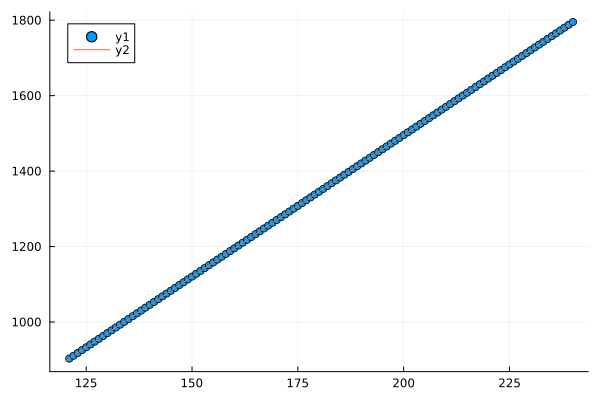

In [11]:
C10s = load("two_point_2leg.jld2", "data")
Ms(L) = sort([k for k in keys(C10s[L])])
C10Ls(L) = [C10s[L][M] for M in Ms(L)];

# linear fit
data(L) = DataFrame(M = Ms(L), logC10 = Float64.(log.(C10Ls(L))))
model(L) = lm(@formula(logC10 ~ M), data(L))

L=6
mesh = 120:0.1:240
plt = scatter(Ms(L), log.(C10Ls(L)))
fit(L) = coef(model(L))
plot!(plt, mesh, fit(L)[1] .+ fit(L)[2].*mesh)
display(plt)

logΛ10(L) = fit(L)[2];

In [12]:
for L in 5:10
    println(1-logΛ10(L)/log(Λ1(L)))
end

# using the linear fit we almost perfectly match the eigenvalues of the transfer matrix,
# down to ~1e-9 at worst, using relatively small cylinders: length 20-50.

0.15981492871107728 + 0.0im
8.92288798404195e-10 + 0.0im
-1.6034928940200643e-10 + 0.0im
-1.6488055365471155e-10 + 0.0im
1.4216783306153502e-10 + 0.0im
-7.428013759636087e-11 + 0.0im


0.21457161605851502


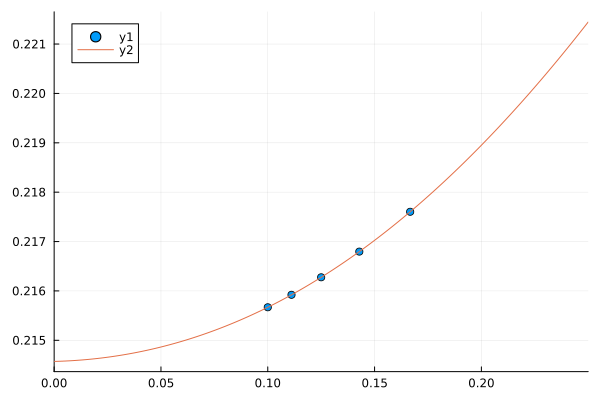

In [13]:
@variables Δ

f10(L) = -logΛ10(L)/L

# get an effective scaling dimension at size L
eq(L) = f10(L)-f0(L) - π*Δ*2/L^2
Δ_eff(L) = Symbolics.value(Symbolics.solve_for(eq(L), Δ))

Lrange = 6:10
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
plot!(xfine, p1.(xfine), xlims=(0, 0.25))

# Two-point function of the current

I now compute the two-point function $\langle \sigma | T^M | \sigma \rangle$, where $\sigma$ is a lattice state in the same module as the current.

## On two antisymmetrised defects
As a first try, it is reasonable to take $\sigma$ to be a state with two defects labeled 1 and 2 which are antisymmetrised, say
$$
|1 2 0 \dots 0 \rangle - |2 1 0 \dots 0 \rangle
$$

where 0 represents an empty site. I extract the corresponding leading eigenvalue thanks to

$$
\langle \sigma |T^M |\sigma \rangle \propto \Lambda^M,
$$

and extrapolate a conformal dimension thanks to the Cardy finite-size formula.

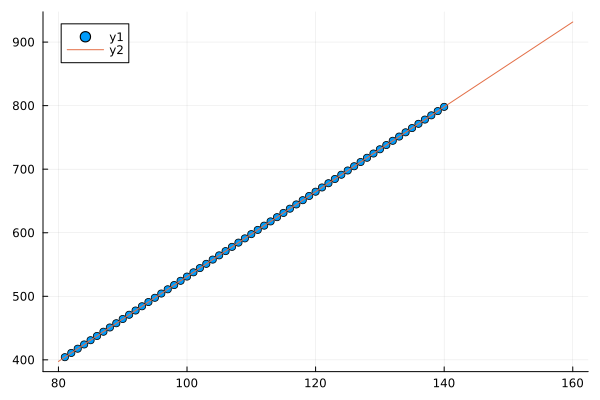

5	1.0342019113404635
6	1.11267656799987
7	1.1600454316761588
8	1.1907842963552497
9	1.2118511526124105
10	1.2269150767697485


In [52]:
C11s = load("two_point_current_antisym.jld2", "data")
Ms(L) = sort([k for k in keys(C11s[L])])
C11Ls(L) = [C11s[L][M] for M in Ms(L)];

# linear fit
data(L) = DataFrame(M = Ms(L), logC11 = Float64.(log.(C11Ls(L))))
model(L) = lm(@formula(logC11 ~ M), data(L))

L=6
mesh = 80:0.1:160
plt = scatter(Ms(L), log.(C11Ls(L)))
fit(L) = coef(model(L))
plot!(plt, mesh, fit(L)[1] .+ fit(L)[2].*mesh)
display(plt)

logΛ11(L) = fit(L)[2];
for L in 5:10
    println(L, "\t", logΛ11(L)/L)
end

1.0003941560302485


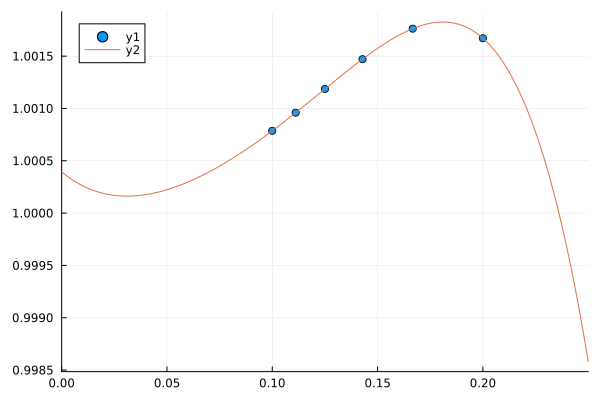

In [53]:
@variables Δ

f11(L) = -logΛ11(L)/L

# get an effective scaling dimension at size L
eq(L) = f11(L)-f0(L) - π*Δ*2/L^2
Δ_eff(L) = Symbolics.value(Symbolics.solve_for(eq(L), Δ))

Lrange = 5:10
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
plot!(xfine, p1.(xfine), xlims=(0, 0.25))

There is a very good convergence to the dimension of the current operator $V_{(1, 1)}$. By projecting on an antisymmetric state at each state we prevent numerical errors from polluting the state with a small symmetric component, hence standard precision numbers are enough to get an accurate result.

In [56]:
J = Field(c, Kac=true, r=1, s=1)
J.Δ[:left] + J.Δ[:right]

1.0000000000000002 + 0.0im

## With Sylvain's prescription for angles

Another possibility is to leave the starting positions of the defects free, and weigh configurations by 

$$
\exp(\frac{is}{2}\sum \theta_k)
$$

where $\theta_i$ is the angle of the defect with label $i$, and $\theta_i \in [\theta_1, \theta_1+2\pi), \ i > 1$

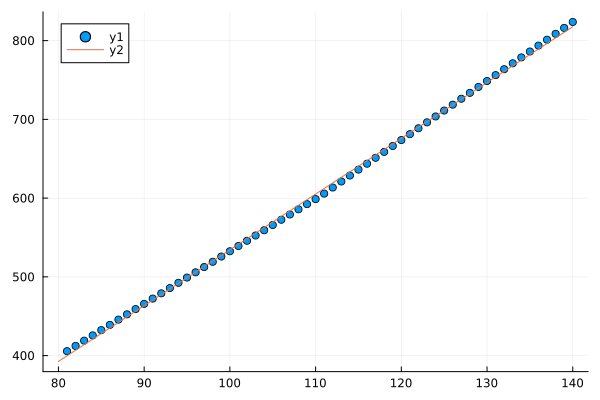

5	1.12601096538809
6	1.1806519269644715
7	1.2072732455104664
8	1.2271275096200482
9	1.241018682602406
10	1.2500268255148648


In [62]:
C11s = load("two_point_current_angles.jld2", "data")
Ms(L) = sort([k for k in keys(C11s[L])])
C11Ls(L) = [C11s[L][M] for M in Ms(L)];

# linear fit
data(L) = DataFrame(M = Ms(L), logC11 = Float64.(log.(abs.(C11Ls(L)))))
model(L) = lm(@formula(logC11 ~ M), data(L))

L=6
mesh = 80:0.1:140
plt = scatter(Ms(L), log.(abs.(C11Ls(L))))
fit(L) = coef(model(L))
plot!(plt, mesh, fit(L)[1] .+ fit(L)[2].*mesh)
display(plt)

logΛ11(L) = fit(L)[2];
for L in 5:10
    println(L, "\t", logΛ11(L)/L)
end

7.919965981134949


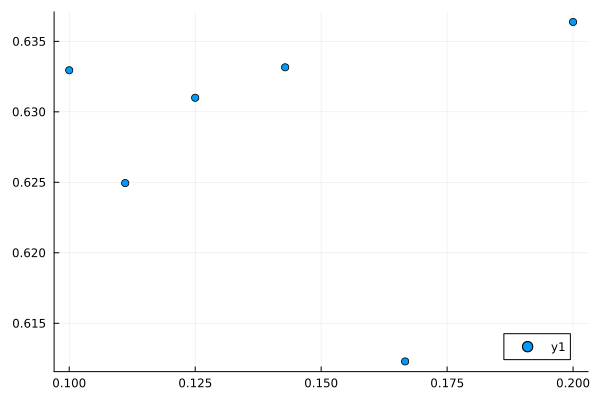

In [63]:
@variables Δ

f11(L) = -logΛ11(L)/L

# get an effective scaling dimension at size L
eq(L) = f11(L)-f0(L) - π*Δ*2/L^2
Δ_eff(L) = Symbolics.value(Symbolics.solve_for(eq(L), Δ))

Lrange = 5:10
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
# plot!(xfine, p1.(xfine), xlims=(0, 0.25))

# Two point function of $(\frac32, \frac23)$

In [17]:
res = load("../results/2pt_3_1.jld2", "res")
Ms(L) = 10*L+1:1:20*L-1
C31Ls(L) = res[L]

# linear fit
data(L) = DataFrame(M = Ms(L), logC31 = Float64.(log.(abs.(C11Ls(L)))))
model(L) = lm(@formula(logC31 ~ M), data(L))

L=6
mesh(L) = Ms(L)[1]:0.1:Ms(L)[end]
plt = scatter(Ms(L), log.(abs.(C31Ls(L))))
fit(L) = coef(model(L))
plot!(plt, mesh(L), fit(L)[1] .+ fit(L)[2].*mesh(L))
display(plt)

logΛ31(L) = fit(L)[2];
for L in 5:9
    println(L, "\t", logΛ31(L)/L)
end

Dict{Any, Any} with 5 entries:
  5 => Complex{BigFloat}[2.83085e+116-2.20786e+17im, 5.27642e+118-3.88596e+19im…
  6 => Complex{BigFloat}[7.51535e+178-9.38172e+79im, 6.23556e+181-7.93366e+82im…
  7 => Complex{BigFloat}[3.39834e+252-3.92966e+153im, 1.18613e+256-1.37158e+157…
  9 => Complex{BigFloat}[3.09878e+433-4.89369e+334im, 1.73833e+438-2.77049e+339…
  8 => Complex{BigFloat}[2.53383e+337-3.97581e+238im, 3.5887e+341-5.68531e+242i…

0.9599670842907887


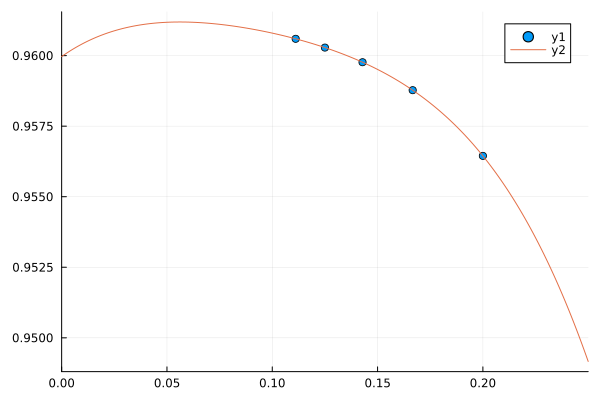

In [46]:
@variables Δ

f31(L) = -logΛ31(L)/L

# get an effective scaling dimension at size L
eq(L) = f31(L)-f0(L) - π*Δ*2/L^2
Δ_eff(L) = Symbolics.value(Symbolics.symbolic_linear_solve(eq(L), Δ))

Lrange = 5:9
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
plot!(xfine, p1.(xfine), xlims=(0, 0.25))

In [53]:
c = CentralCharge(:β, sqrt(4*λ/π))
V = Field(c, Kac=true, r=3//2, s=2//3)
V.Δ[:left] + V.Δ[:right]

0.9615550447311565 + 0.0im

The two point function of the three-leg operator with spin is correct.

# Two point function of $(\frac12, 0)$

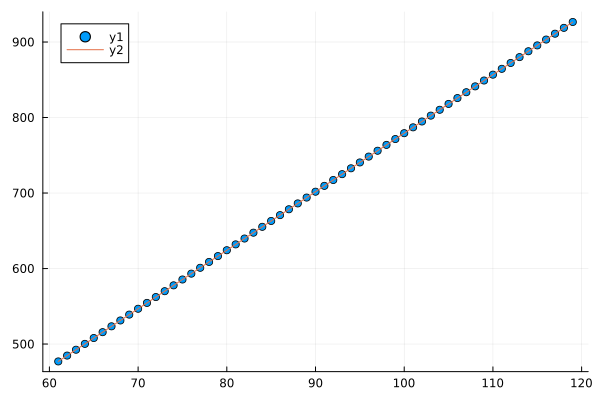

5	1.2920216092978585
6	1.2917324587478813
7	1.2915585565151393
8	1.2914457077209824
9	1.2913683357639796


In [59]:
res = load("../results/2pt_1_0.jld2", "res")
for L in 5:9
    res[L] = BigFloat.(res[L])
end
Ms(L) = 10*L+1:1:20*L-1
C10Ls(L) = res[L]

# linear fit
data(L) = DataFrame(M = Ms(L), logC10 = Float64.(log.(abs.(C11Ls(L)))))
model(L) = lm(@formula(logC10 ~ M), data(L))

L=6
mesh(L) = Ms(L)[1]:0.1:Ms(L)[end]
plt = scatter(Ms(L), log.(abs.(C10Ls(L))))
fit(L) = coef(model(L))
plot!(plt, mesh(L), fit(L)[1] .+ fit(L)[2].*mesh(L))
display(plt)

logΛ10(L) = fit(L)[2];
for L in 5:9
    println(L, "\t", logΛ10(L)/L)
end

-0.02412942451699912


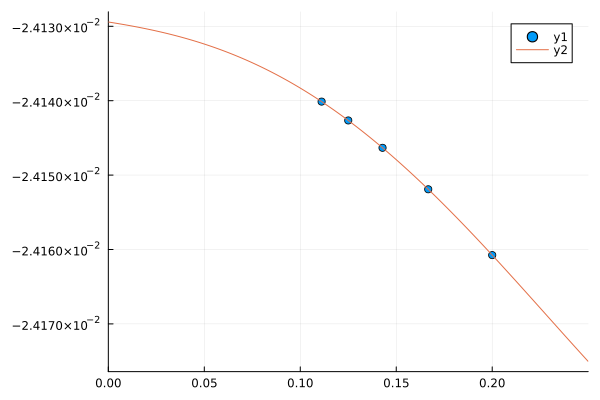

In [61]:
@variables Δ

f10(L) = -logΛ10(L)/L

# get an effective scaling dimension at size L
eq(L) = f10(L)-f0(L) - π*Δ*2/L^2
Δ_eff(L) = Symbolics.value(Symbolics.symbolic_linear_solve(eq(L), Δ))

Lrange = 5:9
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
plot!(xfine, p1.(xfine), xlims=(0, 0.25))

In [62]:
c = CentralCharge(:β, sqrt(4*λ/π))
V = Field(c, Kac=true, r=1//2, s=0)
V.Δ[:left] + V.Δ[:right]

-0.02413057803529113 + 0.0im

The two-point function of the 1-leg operator is correct.